In [24]:
# Following analysis doesn't chase a particular hypothesis to prove, or anything, I use dataset to test my own abilities.

import pandas as pd
df = pd.read_csv("StudentPerformanceFactors.csv")
print(df.shape)     
print(df.columns)    
print(df.head())    
df.tail()

(6607, 20)
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0       

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [25]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [26]:
import seaborn as sns

In [27]:
import matplotlib.pyplot as plt

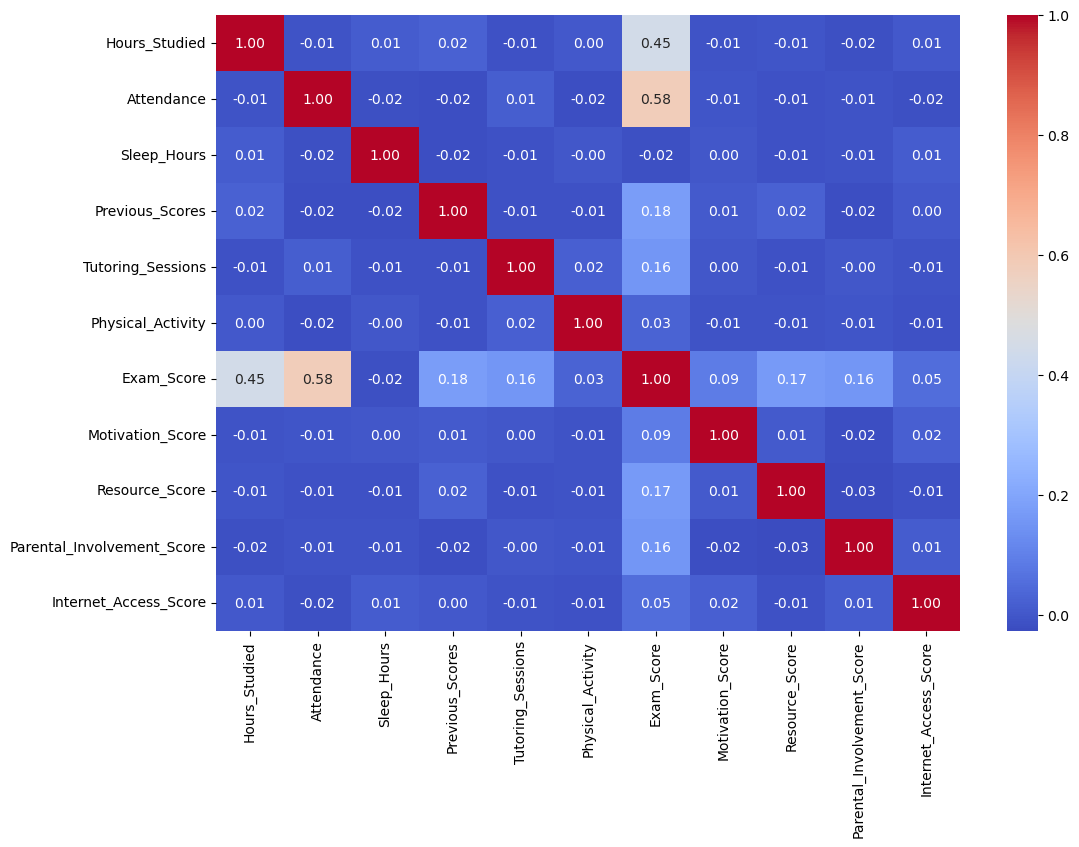

In [28]:
# First of all, I'm using this dataset to analyse correlations between given measurements, starting with heatmap:
level_map = {'Low': 1, 'Medium': 2, 'High': 3}
binary_map = {'Yes': 1, 'No': 0}

df['Motivation_Score'] = df['Motivation_Level'].map(level_map)
df['Resource_Score'] = df['Access_to_Resources'].map(level_map)
df['Parental_Involvement_Score'] = df['Parental_Involvement'].map(level_map)
df['Internet_Access_Score'] = df['Internet_Access'].map(binary_map)

numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f') 

plt.show()


In [29]:
# The biggest surprise? Attendance (0.58) is a stronger predictor than Hours Studied (0.45). It’s not just about how much person works, but how consistent person is. (Surely, considering that this dataset is 'artificial', 
# it's not really describing real-life cases, so don't take everything by heart)

Apart from that, there is a weak linear relationship between Exam Score and Previous Score + Tutoring Sessions, so I consider them as a secondary factors.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Previous_Scores', y='Exam_Score', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Previous Scores vs Exam Score')

#Looking at the heatmap again, it seems clear that other numbers are negligible correlations, so not paying a lot of attention there.

SyntaxError: invalid syntax (649046170.py, line 4)

In [ ]:
# When plotting Exam Scores against School Type, the distributions are nearly identical. The median score stays flat across both categories.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Exam_Score', hue='School_Type', fill=True, palette='viridis')

plt.title('Distribution of Exam Scores: Public vs Private')
plt.xlabel('Exam Score')
plt.ylabel('Density')
plt.show()

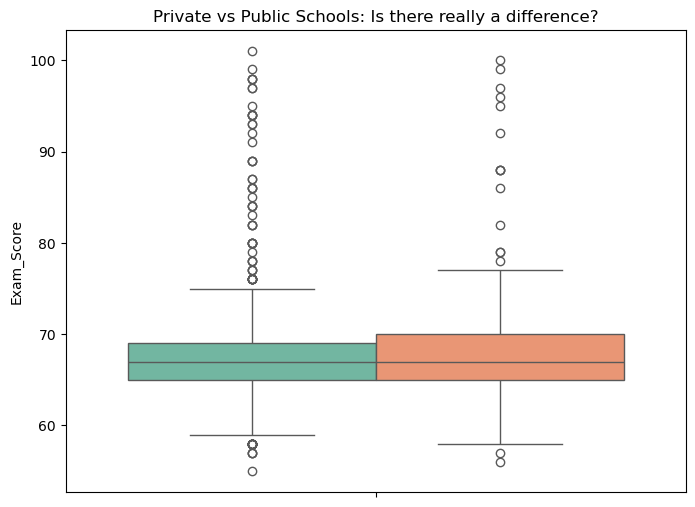

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, hue='School_Type', y='Exam_Score', palette='Set2', legend=False)
plt.title('Private vs Public Schools: Is there really a difference?')
plt.show()

In [31]:
# When plotting Exam Scores against School Type, the distributions are nearly identical. The median score stays flat across both categories.

avg_hours = df['Hours_Studied'].mean()
avg_score = df['Exam_Score'].mean()

outliers = df[(df['Hours_Studied'] < avg_hours) & (df['Exam_Score'] > avg_score + 10)]

print(outliers[['Previous_Scores', 'Exam_Score', 'Teacher_Quality']])

      Previous_Scores  Exam_Score Teacher_Quality
94                 73         100          Medium
217                54          89          Medium
404                53          86          Medium
529                97          97            High
1107               75          89            High
1351               77          82          Medium
1863               76          80            High
2513               60          88            High
2542               80          78          Medium
2595               54          87            High
2687               55          87          Medium
2904               76          88          Medium
2954               95          82          Medium
3124               90          94          Medium
3141               90          86          Medium
3364               63          86          Medium
3457               76          96          Medium
3579               86          99          Medium
3924               79          82            High


In [32]:
# I conducted an outlier analysis to identify 'High-Efficiency' students—those who outperformed their peers despite lower-than-average study hours. 
# I defined this group by filtering for individuals whose study time was below the mean, yet their exam scores were at least 10 points above the population average.
avg_hours = df['Hours_Studied'].mean()
avg_score = df['Exam_Score'].mean()

outliers = df[(df['Hours_Studied'] < avg_hours) & (df['Exam_Score'] > avg_score + 10)]
print(outliers[['Exam_Score', 'Parental_Involvement', 'Tutoring_Sessions', 'Physical_Activity', 'Teacher_Quality']])

# When I looked at 'High-Efficiency' students I found that there are no true shortcuts. The data is remarkably consistent: outliers are rare, and those who do exist usually rely on Medium-High Parental Involvement to bridge the gap.

      Exam_Score Parental_Involvement  Tutoring_Sessions  Physical_Activity  \
94           100                 High                  3                  2   
217           89               Medium                  0                  2   
404           86                  Low                  2                  3   
529           97               Medium                  2                  2   
1107          89                  Low                  1                  4   
1351          82                 High                  1                  2   
1863          80               Medium                  1                  2   
2513          88                 High                  2                  1   
2542          78               Medium                  0                  3   
2595          87               Medium                  1                  2   
2687          87                  Low                  1                  3   
2904          88                 High               